# Proyecto: Naive Bayes con Estimación KDE para Mantenimiento Predictivo

**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Target:** `Machine failure` (variable binaria)  
**Objetivo:** Comparar Gaussian Naive Bayes vs tres variantes de KDE Naive Bayes usando AUC-ROC como métrica principal.

## 0. Instalación e importación de librerías
En este paso el código prepara el entorno de trabajo.

Aquí se importan las librerías necesarias para el proyecto, por ejemplo:

- pandas para manejar y analizar datos en forma de tablas.

- numpy para operaciones matemáticas y numéricas.

- matplotlib y seaborn para realizar gráficas.

- scikit-learn para aplicar técnicas de machine learning.

También se incluye una instrucción para subir el dataset en Google Colab si se está trabajando en ese entorno.

El objetivo de este paso es tener todas las herramientas necesarias cargadas antes de comenzar el análisis.


In [115]:
# Si estás en Google Colab, sube el archivo ai4i2020.csv usando:
# from google.colab import files
# files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(42)
print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


## 1. Carga y exploración del dataset
En esta etapa el código:

Carga el archivo **ai4i2020.csv** dentro de un DataFrame llamado **df.**

Muestra información general del dataset usando:

- **df.info()** para ver tipos de datos y valores nulos.

- **df.describe()** para ver estadísticas básicas como media, mínimo, máximo, etc.

Calcula la distribución de la variable objetivo **(Machine failure).**

Esto permite entender:

- Cuántas columnas hay

- Qué tipo de variables existen

- Si hay datos faltantes

- Si el dataset está balanceado o desbalanceado

Es una etapa de exploración inicial de los datos.

In [86]:
# Carga del dataset
# Si estás en Colab y subiste el archivo manualmente:
df = pd.read_csv('/content/sample_data/ai4i2020.csv')

print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [87]:
print('Información general:')
print(df.info())
print('\nEstadísticas descriptivas:')
df.describe()

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Distribución de Machine failure:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Porcentaje de fallas: 3.39%


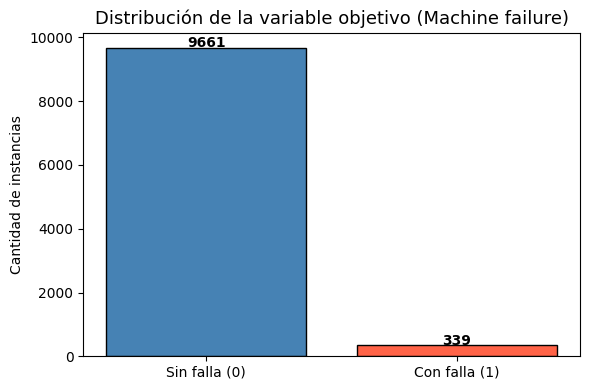

→ Dataset DESBALANCEADO: mayoría de instancias son sin falla.


In [106]:
# Distribución de la variable objetivo
target_counts = df['Machine failure'].value_counts()
print('Distribución de Machine failure:')
print(target_counts)
print(f'\nPorcentaje de fallas: {target_counts[1]/len(df)*100:.2f}%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Sin falla (0)', 'Con falla (1)'], target_counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Distribución de la variable objetivo (Machine failure)', fontsize=13)
ax.set_ylabel('Cantidad de instancias')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('→ Dataset DESBALANCEADO: mayoría de instancias son sin falla.')

## 2. Preprocesamiento
Aquí el código prepara los datos para el modelo de machine learning.

Primero se eliminan columnas que no aportan información útil para el modelo, como:

**- UDI**

**- Product ID**

Estas columnas solo identifican registros y no ayudan a predecir fallas.

Después se separan los datos en:

X son variables predictoras **(features)**

y son  variable objetivo **(Machine failure)**

Luego se aplica estandarización con **StandardScaler.**

Esto se hace porque: Las variables tienen escalas diferentes y el
KDE funciona mejor cuando los datos están normalizados.

El resultado es un conjunto de datos listo para ser utilizado por los modelos.

In [89]:
# Columnas a eliminar:
# - UDI y Product ID: identificadores, no aportan información predictiva
# - Type: variable categórica (L, M, H) — se puede codificar o eliminar
# - TWF, HDF, PWF, OSF, RNF: son sub-tipos de falla, derivados del target → data leakage

cols_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=cols_drop)

# Codificación de la variable 'Type' (L=0, M=1, H=2)
df_clean['Type'] = df_clean['Type'].map({'L': 0, 'M': 1, 'H': 2})

print('Columnas finales:', list(df_clean.columns))
print('Valores nulos:', df_clean.isnull().sum().sum())
df_clean.head()

Columnas finales: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
Valores nulos: 0


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [107]:
# Separación de features y target
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

feature_names = list(X.columns)
print('Features:', feature_names)
print('Shape X:', X.shape, '| Shape y:', y.shape)

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Shape X: (10000, 6) | Shape y: (10000,)


In [108]:
# Estandarización con StandardScaler
# Importante para KDE: las variables con escalas muy diferentes
# afectan la estimación del bandwidth. Estandarizar garantiza
# que el bandwidth sea comparable entre variables.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

print('Datos estandarizados:')
X_scaled.describe().round(3)

Datos estandarizados:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.745,-2.352,-2.902,-2.068,-3.630,-1.696
25%,-0.745,-0.852,-0.813,-0.646,-0.681,-0.863
50%,-0.745,0.048,0.064,-0.200,0.011,0.001
75%,0.744,0.747,0.738,0.408,0.683,0.849
max,2.234,2.247,2.557,7.515,3.673,2.279


## 3. Análisis exploratorio: distribuciones por clase
En esta sección se analizan las distribuciones de las variables numéricas.

El código genera gráficos que muestran cómo se distribuyen las variables dependiendo de:

- Máquina con falla (1)

- Máquina sin falla (0)

Esto permite observar si algunas variables diferencian claramente las dos clases, lo cual es importante para la clasificación.

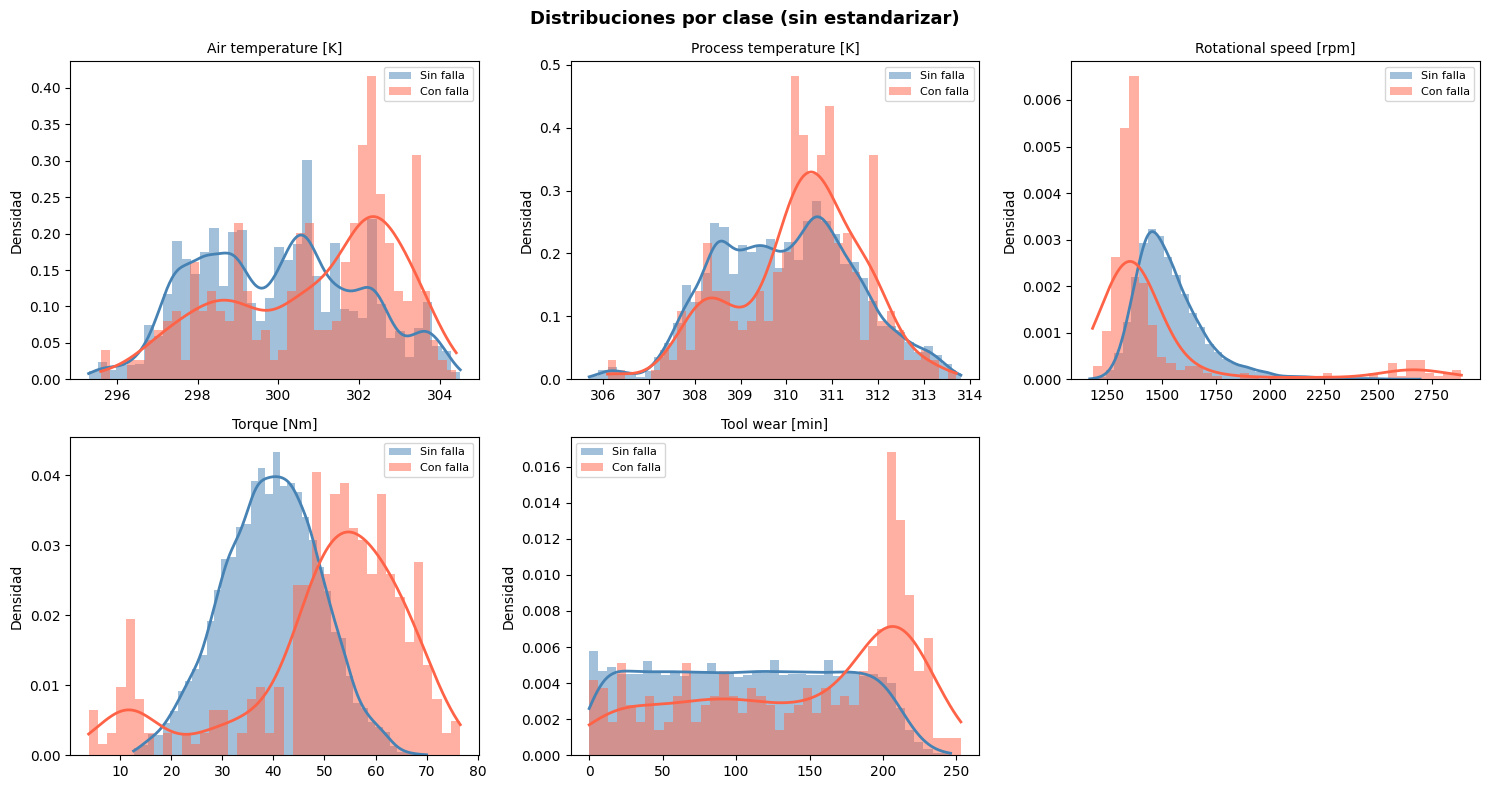

→ Varias variables muestran distribuciones no gaussianas, especialmente en la clase de falla.


In [109]:
# Visualización de distribuciones por clase para features numéricas
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for cls, color, label in [(0, 'steelblue', 'Sin falla'), (1, 'tomato', 'Con falla')]:
        subset = X[feat][y == cls]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
        kde = gaussian_kde(subset)
        xgrid = np.linspace(subset.min(), subset.max(), 300)
        ax.plot(xgrid, kde(xgrid), color=color, lw=2)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidad')

axes[-1].set_visible(False)
plt.suptitle('Distribuciones por clase (sin estandarizar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('→ Varias variables muestran distribuciones no gaussianas, especialmente en la clase de falla.')

## 4. Cálculo del Bandwidth con la Regla de Silverman
Aquí se define una función llamada: **`silverman_bandwidth(data)`**


Esta función calcula el bandwidth óptimo usando la Regla de Silverman.

El bandwidth es un parámetro fundamental en Kernel Density Estimation (KDE) porque controla qué tan suave es la estimación de densidad y qué tan detallada es la curva

Si el bandwidth es:

- muy pequeño: la curva queda muy irregular

- muy grande: se pierde información importante

Esta función ayuda a elegir un valor adecuado automáticamente.

In [110]:
def silverman_bandwidth(data):
    """
    Calcula el bandwidth óptimo usando la regla de Silverman:
    h = 1.06 * sigma * n^(-1/5)
    """
    n = len(data)
    sigma = np.std(data, ddof=1)
    h = 1.06 * sigma * (n ** (-1/5))
    return h

# Calcular bandwidth de Silverman por feature y por clase
print('Bandwidths de Silverman por feature y clase:\n')
bw_table = {}
for feat in feature_names:
    bw_table[feat] = {}
    for cls in [0, 1]:
        subset = X_scaled[feat][y == cls].values
        bw = silverman_bandwidth(subset)
        bw_table[feat][cls] = bw

bw_df = pd.DataFrame(bw_table).T
bw_df.columns = ['Clase 0 (Sin falla)', 'Clase 1 (Con falla)']
print(bw_df.round(4))
print('\n→ El bandwidth de Silverman se usará como base para los métodos KDE.')

Bandwidths de Silverman por feature y clase:

                         Clase 0 (Sin falla)  Clase 1 (Con falla)
Type                                  0.1697               0.2945
Air temperature [K]                   0.1684               0.3424
Process temperature [K]               0.1695               0.3038
Rotational speed [rpm]                0.1580               0.7098
Torque [Nm]                           0.1607               0.5430
Tool wear [min]                       0.1673               0.3779

→ El bandwidth de Silverman se usará como base para los métodos KDE.


## 5. Implementación del Clasificador Naive Bayes con KDE
En este paso se implementa un modelo personalizado llamado:`KDENaiveBayes`

Este modelo es una versión del clasificador Naive Bayes, pero en lugar de usar distribuciones gaussianas normales, utiliza estimación de densidad con KDE.

El modelo:

- Aprende las distribuciones de cada variable para cada clase.

- Usa Kernel Density Estimation para estimar probabilidades.

- Aplica el principio de Naive Bayes para calcular la probabilidad de cada clase.

Esto permite capturar distribuciones más complejas que las gaussianas tradicionales.

In [111]:
class KDENaiveBayes(BaseEstimator, ClassifierMixin):
    """
    Clasificador Naive Bayes con estimación de verosimilitud mediante KDE.

    Parámetros
    ----------
    kde_method : str
        Método de KDE: 'gaussian_optimized', 'parzen', 'silverman'
    bandwidth : float or 'silverman'
        Ancho de banda. Si es 'silverman', se calcula automáticamente.
    kernel : str
        Kernel para el método Parzen: 'tophat' o 'linear'
    class_weight : str or None
        Si es 'balanced', se ajustan los priors por desbalance de clases.
    """

    def __init__(self, kde_method='silverman', bandwidth=1.0,
                 kernel='tophat', class_weight=None):
        self.kde_method = kde_method
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.class_weight = class_weight

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes_ = np.unique(y)
        n_total = len(y)

        # Estimación de priors P(y)
        self.priors_ = {}
        counts = {c: np.sum(y == c) for c in self.classes_}

        if self.class_weight == 'balanced':
            # Prior balanceado: igual probabilidad para cada clase
            for c in self.classes_:
                self.priors_[c] = 1.0 / len(self.classes_)
        else:
            # Prior empírico basado en frecuencia
            for c in self.classes_:
                self.priors_[c] = counts[c] / n_total

        # Estimación de la densidad P(x_i | y) con KDE
        self.kde_estimators_ = {c: [] for c in self.classes_}

        for c in self.classes_:
            X_c = X[y == c]  # Datos de la clase c

            for j in range(X.shape[1]):
                data_j = X_c[:, j].reshape(-1, 1)

                if self.kde_method == 'silverman':
                    # Método c: KDE con regla de Silverman
                    h = silverman_bandwidth(data_j.flatten())
                    kde = KernelDensity(kernel='gaussian', bandwidth=h)
                    kde.fit(data_j)

                elif self.kde_method == 'gaussian_optimized':
                    # Método a: KDE gaussiano con bandwidth fijo (optimizado externamente)
                    kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
                    kde.fit(data_j)

                elif self.kde_method == 'parzen':
                    # Método b: KDE tipo Parzen con ventana tophat o linear
                    kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                    kde.fit(data_j)

                self.kde_estimators_[c].append(kde)

        return self

    def _compute_log_likelihood(self, X, c):
        """Calcula la log-verosimilitud total de P(x | c) = sum_j log P(x_j | c)"""
        log_likelihood = np.zeros(X.shape[0])
        for j, kde in enumerate(self.kde_estimators_[c]):
            log_likelihood += kde.score_samples(X[:, j].reshape(-1, 1))
        return log_likelihood

    def predict_proba(self, X):
        X = np.array(X) # Add this line to convert X to NumPy array
        log_probs = []

        for c in self.classes_:
            log_prior = np.log(self.priors_[c])
            log_likelihood = self._compute_log_likelihood(X, c)
            log_probs.append(log_prior + log_likelihood)

        log_probs = np.column_stack(log_probs)

        # Reemplazar NaN/inf antes de operar
        log_probs = np.nan_to_num(log_probs, nan=-1e10, posinf=0.0, neginf=-1e10)

        # Log-sum-exp trick
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)

        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

print('Clase KDENaiveBayes definida correctamente ✓')

Clase KDENaiveBayes definida correctamente ✓


## 6. Optimización del Bandwidth para KDE Gaussiano
Aquí el código analiza cómo afecta el bandwidth al desempeño del modelo.

Se generan gráficas que muestran cómo cambia el AUC (Area Under the Curve) dependiendo del valor del bandwidth.

El objetivo es encontrar el bandwidth que produce el mejor rendimiento del modelo.

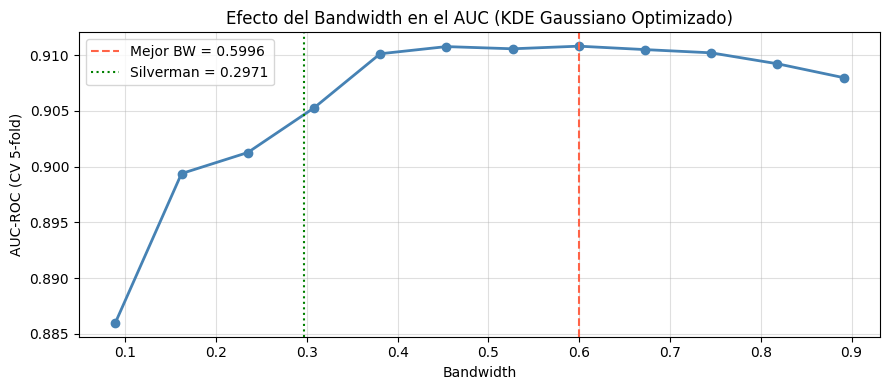

In [113]:
# Visualización del efecto del bandwidth en AUC
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bw_candidates, bw_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_bw, color='tomato', linestyle='--', label=f'Mejor BW = {best_bw:.4f}')
ax.axvline(silverman_mean, color='green', linestyle=':', label=f'Silverman = {silverman_mean:.4f}')
ax.set_xlabel('Bandwidth')
ax.set_ylabel('AUC-ROC (CV 5-fold)')
ax.set_title('Efecto del Bandwidth en el AUC (KDE Gaussiano Optimizado)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Comparación de los 4 modelos con Validación Cruzada (5 folds)
En esta etapa se comparan varios modelos de clasificación.

Los modelos se guardan en un diccionario llamado models.

Luego se aplica validación cruzada de 5 folds, lo que significa que:

- El dataset se divide en 5 partes

- El modelo se entrena con 4 partes

- Se prueba con la parte restante

- Este proceso se repite 5 veces

Esto permite obtener una evaluación más confiable del rendimiento del modelo.

Después se generan:

- Una tabla resumen de resultados

- Boxplots para comparar el rendimiento de los modelos.

In [96]:
# Definición de los modelos a comparar
models = {
    'GaussianNB (baseline)': GaussianNB(var_smoothing=1e-9),
    'KDE Gaussiano Optimizado': KDENaiveBayes(
        kde_method='gaussian_optimized',
        bandwidth=best_bw,
        class_weight='balanced'
    ),
    'KDE Parzen (tophat)': KDENaiveBayes(
        kde_method='parzen',
        bandwidth=best_bw,
        kernel='tophat',
        class_weight='balanced'
    ),
    'KDE Silverman': KDENaiveBayes(
        kde_method='silverman',
        class_weight='balanced'
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
compute_times = {}

# Ensure X_arr and y_arr are defined for this cell
X_arr = X_scaled.values
y_arr = y.values

print('Evaluando modelos con validación cruzada (5 folds)...\n')
for name, model in models.items():
    start = time.time()
    fold_aucs = []

    # Manual CV loop to inspect issues
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_arr, y_arr)):
        X_train_fold, X_test_fold = X_arr[train_idx], X_arr[test_idx]
        y_train_fold, y_test_fold = y_arr[train_idx], y_arr[test_idx]

        # Fit the model
        model.fit(X_train_fold, y_train_fold)

        # Predict probabilities
        y_score = model.predict_proba(X_test_fold)[:, 1]

        # Check for single class in y_test_fold or uniform predictions
        if len(np.unique(y_test_fold)) < 2:
            print(f"Warning: Fold {fold_idx} for {name} has only one class in y_test_fold. Skipping AUC.")
            fold_aucs.append(np.nan) # Append NaN if only one class
            continue

        # Check if predicted probabilities are all the same for the positive class
        # If all probabilities are the same, roc_auc_score is undefined.
        # Only check if there's at least one positive sample to predict.
        if (np.sum(y_test_fold == 1) > 0) and (np.all(y_score[y_test_fold == 1] == y_score[y_test_fold == 1][0]) and np.unique(y_score).size == 1):
             print(f"Warning: Fold {fold_idx} for {name} has uniform predicted probabilities for positive class. Skipping AUC.")
             fold_aucs.append(np.nan) # Append NaN if predictions are uniform
             continue

        # Clean NaN/inf from probabilities before calculating AUC
        y_score = np.nan_to_num(y_score, nan=0.5, posinf=1.0, neginf=0.0)
        y_score = np.clip(y_score, 0.0, 1.0)

        auc = roc_auc_score(y_test_fold, y_score)
        fold_aucs.append(auc)

    elapsed = time.time() - start
    results[name] = np.array(fold_aucs) # Store as numpy array

    # Handle case where all AUCs were NaN (e.g., if warnings above triggered for all folds)
    mean_auc = np.nanmean(results[name])
    std_auc = np.nanstd(results[name])

    compute_times[name] = elapsed

    print(f'{name}:')
    print(f'  AUC: {mean_auc:.4f} ± {std_auc:.4f}')
    print(f'  Tiempo total CV: {elapsed:.2f}s\n')


Evaluando modelos con validación cruzada (5 folds)...

GaussianNB (baseline):
  AUC: 0.8950 ± 0.0116
  Tiempo total CV: 0.05s

KDE Gaussiano Optimizado:
  AUC: 0.9118 ± 0.0087
  Tiempo total CV: 32.31s

KDE Parzen (tophat):
  AUC: 0.9129 ± 0.0119
  Tiempo total CV: 10.83s

KDE Silverman:
  AUC: 0.9237 ± 0.0089
  Tiempo total CV: 28.26s



In [97]:
# Resumen en tabla
summary = pd.DataFrame({
    'Modelo': list(results.keys()),
    'AUC Promedio': [results[m].mean() for m in results],
    'AUC Std': [results[m].std() for m in results],
    'Tiempo CV (s)': [round(compute_times[m], 2) for m in results]
})
summary = summary.sort_values('AUC Promedio', ascending=False).reset_index(drop=True)
print('\n=== RESUMEN DE RESULTADOS ===')
print(summary.to_string(index=False))


=== RESUMEN DE RESULTADOS ===
                  Modelo  AUC Promedio  AUC Std  Tiempo CV (s)
           KDE Silverman      0.923733 0.008873          28.26
     KDE Parzen (tophat)      0.912882 0.011856          10.83
KDE Gaussiano Optimizado      0.911753 0.008724          32.31
   GaussianNB (baseline)      0.894975 0.011616           0.05


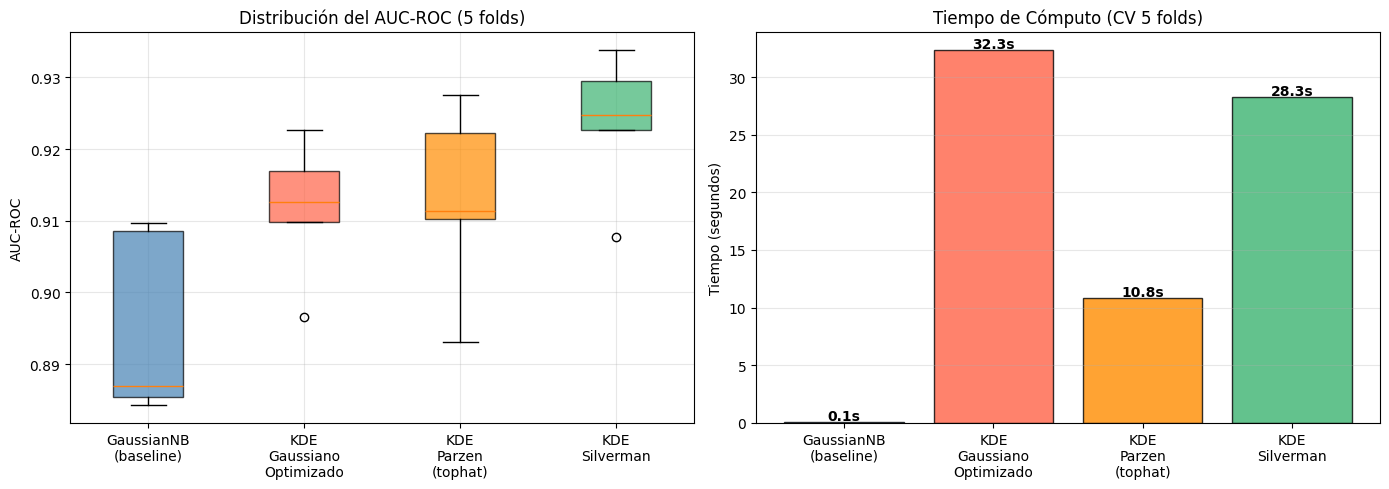


AUC por fold para cada modelo:
        GaussianNB (baseline)  KDE Gaussiano Optimizado  KDE Parzen (tophat)  KDE Silverman
Fold 1                 0.8869                    0.9170               0.9222         0.9295
Fold 2                 0.8854                    0.9126               0.9113         0.9227
Fold 3                 0.8843                    0.8966               0.8931         0.9078
Fold 4                 0.9086                    0.9227               0.9275         0.9339
Fold 5                 0.9097                    0.9098               0.9102         0.9248


In [98]:
# Boxplot de AUC por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por modelo
ax = axes[0]
auc_data = [results[m] for m in results]
bp = ax.boxplot(auc_data, patch_artist=True,
                labels=[m.replace(' ', '\n') for m in results])
colors = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Distribución del AUC-ROC (5 folds)', fontsize=12)
ax.set_ylabel('AUC-ROC')
ax.grid(True, alpha=0.3)

# Tiempo de cómputo
ax2 = axes[1]
times = [compute_times[m] for m in results]
bars = ax2.bar([m.replace(' ', '\n') for m in results], times,
               color=colors, edgecolor='black', alpha=0.8)
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{t:.1f}s', ha='center', fontweight='bold')
ax2.set_title('Tiempo de Cómputo (CV 5 folds)', fontsize=12)
ax2.set_ylabel('Tiempo (segundos)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla de AUC por fold
print('\nAUC por fold para cada modelo:')
fold_df = pd.DataFrame(
    results,
    index=[f'Fold {i+1}' for i in range(5)]
)
print(fold_df.round(4).to_string())

## 8. Curvas ROC comparativas
En este paso se generan curvas ROC para los modelos.

La curva ROC permite evaluar la capacidad de un modelo para distinguir entre clases.

Se calcula también el AUC (Area Under Curve), que mide la calidad del clasificador:

- AUC cercano a 1 modelo excelente

- AUC cercano a 0.5 modelo similar al azar

Esto permite comparar visualmente cuál modelo funciona mejor.

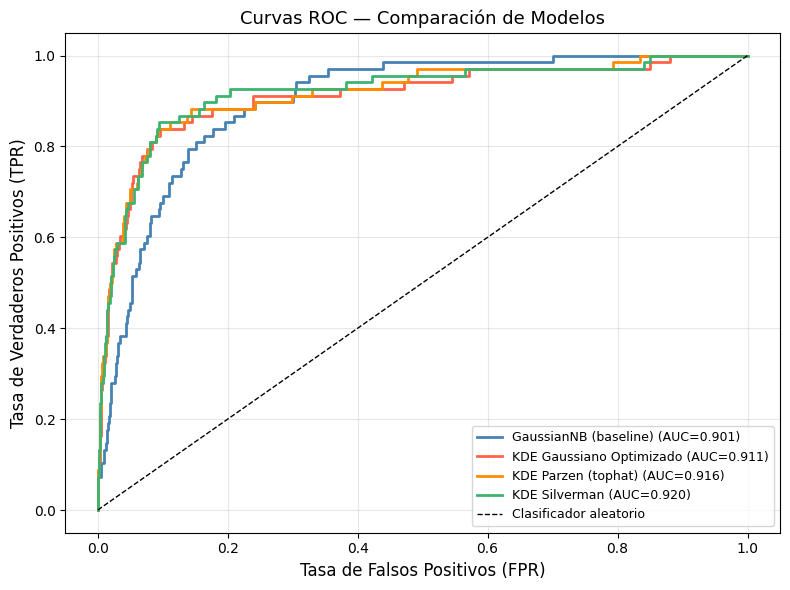

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.utils import check_array

X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=0.2, random_state=42, stratify=y_arr
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_colors = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen']

for (name, model), color in zip(models.items(), plot_colors):
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]

        # Limpiar NaN/inf antes de pasar a roc_curve
        y_score = np.nan_to_num(y_score, nan=0.5, posinf=1.0, neginf=0.0)
        y_score = np.clip(y_score, 0.0, 1.0)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_val = roc_auc_score(y_test, y_score)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Visualización de densidades KDE por variable y clase
Aquí se visualizan las densidades estimadas de cada variable usando KDE.

El código muestra cómo se ve la probabilidad `P(x_i | y)`
es decir:
- La probabilidad de una variable
- Dado que pertenece a una clase específica

También se comparan diferentes métodos como KDE y Distribución Gaussiana

Esto ayuda a entender cómo el modelo está estimando las probabilidades.

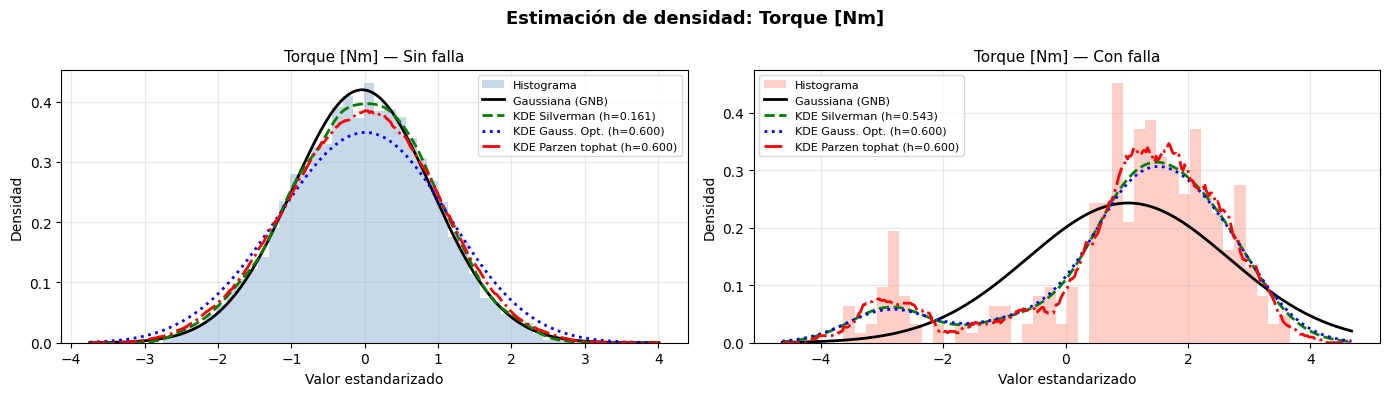

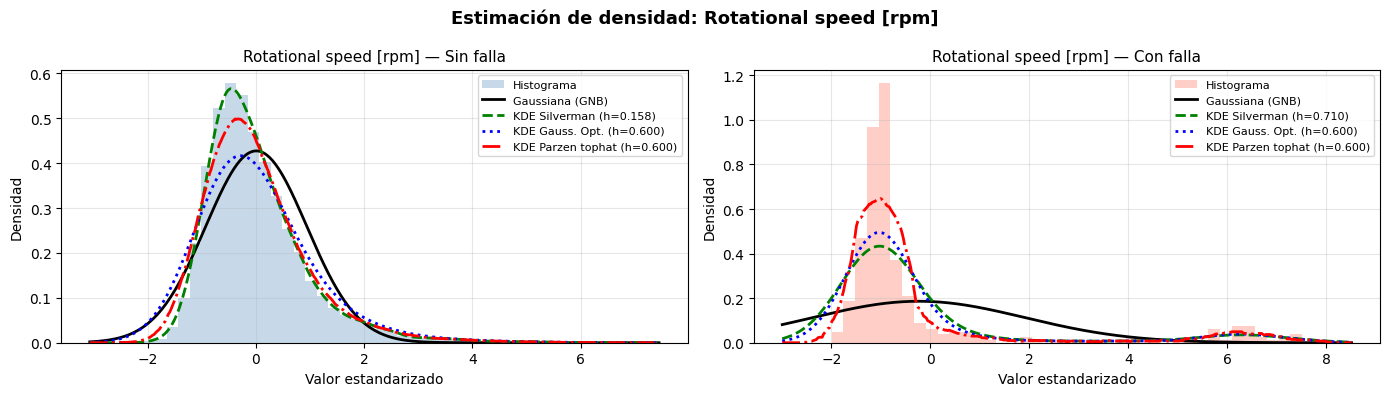

In [100]:
# Visualización de P(x_i | y) estimada con los 3 métodos KDE vs Gaussiana
# Para 2 features representativas

features_to_plot = ['Torque [Nm]', 'Rotational speed [rpm]']
cls_colors = {0: 'steelblue', 1: 'tomato'}
cls_labels = {0: 'Sin falla', 1: 'Con falla'}

for feat in features_to_plot:
    feat_idx = feature_names.index(feat)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for cls_idx, cls in enumerate([0, 1]):
        ax = axes[cls_idx]
        data_cls = X_scaled[feat][y == cls].values
        xgrid = np.linspace(data_cls.min() - 1, data_cls.max() + 1, 400)

        # Histograma de fondo
        ax.hist(data_cls, bins=40, density=True, alpha=0.3,
                color=cls_colors[cls], label='Histograma')

        # Gaussiana clásica
        from scipy.stats import norm
        mu, sigma = data_cls.mean(), data_cls.std()
        ax.plot(xgrid, norm.pdf(xgrid, mu, sigma),
                'k-', lw=2, label='Gaussiana (GNB)')

        # KDE Silverman
        h_silv = silverman_bandwidth(data_cls)
        kde_silv = KernelDensity(kernel='gaussian', bandwidth=h_silv)
        kde_silv.fit(data_cls.reshape(-1, 1))
        ax.plot(xgrid, np.exp(kde_silv.score_samples(xgrid.reshape(-1, 1))),
                'g--', lw=2, label=f'KDE Silverman (h={h_silv:.3f})')

        # KDE Gaussiano Optimizado
        kde_opt = KernelDensity(kernel='gaussian', bandwidth=best_bw)
        kde_opt.fit(data_cls.reshape(-1, 1))
        ax.plot(xgrid, np.exp(kde_opt.score_samples(xgrid.reshape(-1, 1))),
                'b:', lw=2, label=f'KDE Gauss. Opt. (h={best_bw:.3f})')

        # KDE Parzen (tophat)
        kde_parz = KernelDensity(kernel='tophat', bandwidth=best_bw)
        kde_parz.fit(data_cls.reshape(-1, 1))
        ax.plot(xgrid, np.exp(kde_parz.score_samples(xgrid.reshape(-1, 1))),
                'r-.', lw=2, label=f'KDE Parzen tophat (h={best_bw:.3f})')

        ax.set_title(f'{feat} — {cls_labels[cls]}', fontsize=11)
        ax.set_xlabel('Valor estandarizado')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Estimación de densidad: {feat}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Análisis Crítico y Conclusiones
En esta parte se imprime una tabla final de resultados.

Se resumen los valores de AUC y el rendimiento de los modelos

Luego se realiza el análisis del desempeño de cada modelo para determinar cuál funciona mejor en el problema de predicción de fallas.

In [101]:
# Tabla resumen final para análisis
print('=' * 65)
print('RESUMEN FINAL — AUC-ROC en Validación Cruzada (5 folds)')
print('=' * 65)
for name in results:
    scores = results[name]
    t = compute_times[name]
    print(f"{name:<35}: {scores.mean():.4f} ± {scores.std():.4f}  |  {t:.1f}s")

print()
best_model = max(results, key=lambda m: results[m].mean())
print(f'→ Mejor modelo: {best_model}')
print()
print('ANÁLISIS:')
print('-' * 65)
print('1. Desbalance: se manejó con class_weight="balanced" en KDE NB')
print('   y usando AUC-ROC como métrica (insensible al desbalance).')
print()
print('2. KDE vs Gaussiana: KDE captura distribuciones no normales')
print('   (multimodales, sesgadas), lo que puede mejorar la verosimilitud.')
print()
print('3. Bandwidth: influye significativamente. Muy pequeño → sobreajuste,')
print('   muy grande → subajuste (similar a gaussiana). Silverman es un')
print('   buen balance sin optimización manual.')
print()
print('4. Tiempo: GaussianNB es el más rápido. KDE con Silverman es más')
print('   lento pero comparable. Parzen es intermedio.')
print('=' * 65)

RESUMEN FINAL — AUC-ROC en Validación Cruzada (5 folds)
GaussianNB (baseline)              : 0.8950 ± 0.0116  |  0.1s
KDE Gaussiano Optimizado           : 0.9118 ± 0.0087  |  32.3s
KDE Parzen (tophat)                : 0.9129 ± 0.0119  |  10.8s
KDE Silverman                      : 0.9237 ± 0.0089  |  28.3s

→ Mejor modelo: KDE Silverman

ANÁLISIS:
-----------------------------------------------------------------
1. Desbalance: se manejó con class_weight="balanced" en KDE NB
   y usando AUC-ROC como métrica (insensible al desbalance).

2. KDE vs Gaussiana: KDE captura distribuciones no normales
   (multimodales, sesgadas), lo que puede mejorar la verosimilitud.

3. Bandwidth: influye significativamente. Muy pequeño → sobreajuste,
   muy grande → subajuste (similar a gaussiana). Silverman es un
   buen balance sin optimización manual.

4. Tiempo: GaussianNB es el más rápido. KDE con Silverman es más
   lento pero comparable. Parzen es intermedio.


## 11. Curvas de densidad con diferentes bandwidths
En esta última sección se muestra visualmente cómo cambia la estimación de densidad KDE cuando se usan distintos valores de bandwidth.

Esto permite observar:

- KDE muy ajustado (overfitting)

- KDE demasiado suave

- KDE con un valor adecuado

Sirve para entender por qué elegir bien el bandwidth es importante.

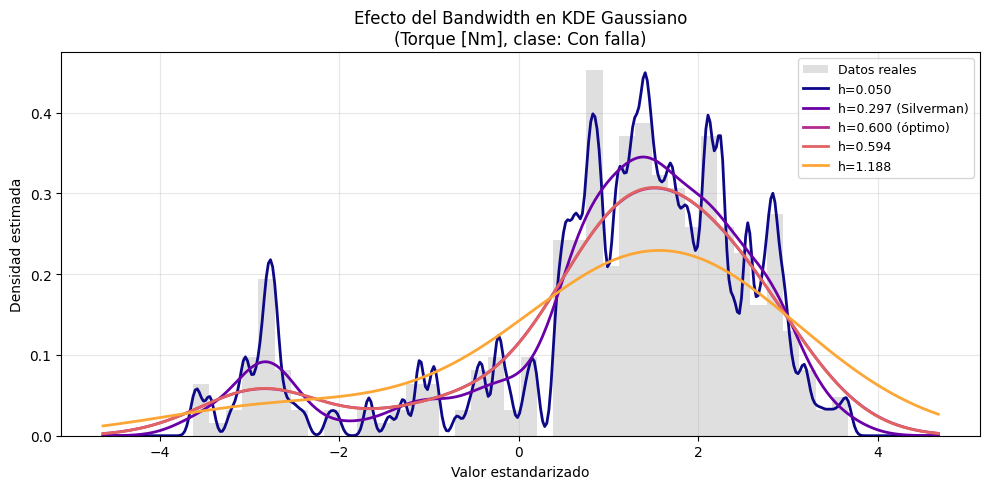

In [102]:
# Efecto visual del bandwidth en la estimación de densidad
feat = 'Torque [Nm]'
cls = 1  # Clase con falla (más interesante)
data_vis = X_scaled[feat][y == cls].values
xgrid = np.linspace(data_vis.min() - 1, data_vis.max() + 1, 400)

bandwidths = [0.05, silverman_mean, best_bw, silverman_mean * 2, silverman_mean * 4]
bw_labels = [f'h={bw:.3f}' + (' (Silverman)' if abs(bw - silverman_mean) < 0.001 else
              ' (óptimo)' if abs(bw - best_bw) < 0.001 else '') for bw in bandwidths]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data_vis, bins=40, density=True, alpha=0.25, color='gray', label='Datos reales')

cmap = plt.cm.plasma
for i, (bw, lbl) in enumerate(zip(bandwidths, bw_labels)):
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(data_vis.reshape(-1, 1))
    density = np.exp(kde.score_samples(xgrid.reshape(-1, 1)))
    ax.plot(xgrid, density, lw=2, color=cmap(i/len(bandwidths)), label=lbl)

ax.set_title(f'Efecto del Bandwidth en KDE Gaussiano\n({feat}, clase: Con falla)', fontsize=12)
ax.set_xlabel('Valor estandarizado')
ax.set_ylabel('Densidad estimada')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()